In [1]:
import yaml
import numpy as np
import polars as pl
import polars.selectors as cs
from tqdm import tqdm
import statsmodels.api as sm
from scipy import stats

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Configuration and paths
mac = 20

# ============================================================
# Variant class selection — change this to switch variant class
# Available: missense, missense_structured, missense_non_structured,
#   missense_disordered, missense_lip, intron,
#   enhancer_encode, promoter_encode, tf_encode, core_promoter
# ============================================================
variant_class = 'missense'
exclude_clinvar = False  # Independent toggle: exclude ClinVar-annotated variants
only_clinvar = False  # Independent toggle: include only ClinVar-annotated variants

# Initialize new annotation variable as None
new_anno_local = None

# Define top-N per gene for the heatmap
target_k = np.array([3, 5, 10], dtype=np.int64)  # top-N variants per gene

# Tie-breaking for equal annotation scores within a gene:
# True  → break ties by phenotype z-score (descending); picks best-performing tied variants
# False → break ties arbitrarily (ordinal/first-occurrence)
zscore_tiebreak = False

# Load variant class configuration
variant_class_path = "/home/dnanexus/ukbgym/config_variant_classes.yaml"
with open(variant_class_path) as f:
    variant_class_config = yaml.safe_load(f)

vc = variant_class_config[variant_class]
vc_filters = vc['variant_filtering']
selected_categories = vc['tool_categories']
x_label = f"Top N {vc['x_label']} variants"

print(f"Variant class: {variant_class}")
print(f"  Filters: {vc_filters}")
print(f"  Categories: {selected_categories}")
print(f"  X-label: {x_label}")
print(f"  Exclude ClinVar: {exclude_clinvar}")

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_odds.yaml"

with open(config_path) as f:
    config = yaml.safe_load(f)

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

Variant class: missense
  Filters: ["pl.col('consequence_missense_variant') == True"]
  Categories: ['missense']
  X-label: Top N Missense variants
  Exclude ClinVar: False


category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""missense""","""clinpred_score""","""#FFDC80""","""ClinPred""",1
"""missense""","""bayes_del""","""#FFBF00""","""BayesDel""",1
"""missense""","""polyphen""","""#FF90AA""","""PolyPhen2""",1
"""missense""","""revel_score""","""#FF7000""","""REVEL""",1
"""missense""","""am_pathogenicity""","""#E63946""","""AlphaMissense""",1
…,…,…,…,…
"""regulatory""","""fz_gtex_max""","""#9467BD""","""Flashzoi max across RNA (GTEx)""",1
"""regulatory""","""fz_all_min""","""#00A99D""","""Flashzoi min across RNA (all)""",-1
"""regulatory""","""fz_all_max""","""#00A99D""","""Flashzoi max across RNA (all)""",1


In [3]:
# Get gene trait associations
RAP_DIR = 'project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results'

# ASSOC_FILE = 'loftee_mac20_associations_bh_corrected.parquet'
# ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR.parquet'
ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per.parquet'

LOCAL_DIR = '/home/dnanexus/data_dir/'

!dx download {RAP_DIR}/{ASSOC_FILE} -o {LOCAL_DIR}

gene_trait_df = (
    pl.read_parquet(f'{LOCAL_DIR}/{ASSOC_FILE}')
    .filter(pl.col('pval_fdr')<=0.05)
    .select(['region', 'phenotype', 'pval_fdr'])
)

# CORR_FILE = 'regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet'
CORR_FILE = "regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per_correlations.parquet"
!dx download {RAP_DIR}/{CORR_FILE} -o {LOCAL_DIR}

loftee_corrs = (
    pl.read_parquet(f'{LOCAL_DIR}/{CORR_FILE}')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

gene_trait_df = (
    gene_trait_df
    .join(loftee_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    .sort('loftee_corr_abs', descending=True)
    .unique(subset=["region"], keep="first", maintain_order=True)
)
gene_trait_df

Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR_
miss20per.parquet" already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR_
miss20per_correlations.parquet" already exists but -f/--overwrite was not set


region,phenotype,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64,f64
"""ENSG00000084674""","""ldl_direct_int""",2.2543e-301,-0.12678,0.12678,-1.0
"""ENSG00000167701""","""alanine_aminotransferase_int""",1.2234e-144,-0.106424,0.106424,-1.0
"""ENSG00000105610""","""mean_corpuscular_haemoglobin_i…",9.8993e-24,-0.100921,0.100921,-1.0
"""ENSG00000141505""","""alkaline_phosphatase_int""",8.4146e-35,0.089171,0.089171,1.0
"""ENSG00000101162""","""platelet_distribution_width_in…",1.5335e-83,0.08869,0.08869,1.0
…,…,…,…,…,…
"""ENSG00000115977""","""sitting_height_int""",0.021257,-0.001496,0.001496,-1.0
"""ENSG00000119574""","""standing_height_int""",0.025535,-0.001317,0.001317,-1.0
"""ENSG00000115325""","""platelet_distribution_width_in…",0.01277,-0.001204,0.001204,-1.0


In [4]:
new_anno_path = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/flashzoi_scores"
new_anno_filename = "ukbbgym_TSS_promoter_enhancer_TF_variants_GENCODEv39_260218_rep0.parquet"
!dx download {new_anno_path}/{new_anno_filename} -o /home/dnanexus/data_dir/

new_anno_local = f'/home/dnanexus/data_dir/{new_anno_filename}'

new_anno_df = pl.scan_parquet(new_anno_local)
# rna_cols = [c for c in new_anno_df.collect_schema().names() if c.startswith('RNA:')]
# 89 GTEx tissue tracks:
gtex_cols = ['RNA:adipose_tissue_7522', 'RNA:adipose_tissue_7523', 'RNA:adipose_tissue_7524', 'RNA:adrenal_gland_7525', 'RNA:adrenal_gland_7526', 'RNA:adrenal_gland_7527', 'RNA:bladder_7528', 'RNA:bladder_7529', 'RNA:bladder_7530', 'RNA:blood_7531', 'RNA:blood_7532', 'RNA:blood_7533', 'RNA:blood_vessel_7534', 'RNA:blood_vessel_7535', 'RNA:blood_vessel_7536', 'RNA:bone_marrow_7537', 'RNA:bone_marrow_7538', 'RNA:brain_7539', 'RNA:brain_7540', 'RNA:brain_7541', 'RNA:breast_7542', 'RNA:breast_7543', 'RNA:breast_7544', 'RNA:cervix_uteri_7545', 'RNA:cervix_uteri_7546', 'RNA:cervix_uteri_7547', 'RNA:colon_7548', 'RNA:colon_7549', 'RNA:colon_7550', 'RNA:esophagus_7551', 'RNA:esophagus_7552', 'RNA:esophagus_7553', 'RNA:fallopian_tube_7554', 'RNA:fallopian_tube_7555', 'RNA:fallopian_tube_7556', 'RNA:heart_7557', 'RNA:heart_7558', 'RNA:heart_7559', 'RNA:kidney_7560', 'RNA:kidney_7561', 'RNA:kidney_7562', 'RNA:liver_7563', 'RNA:liver_7564', 'RNA:liver_7565', 'RNA:lung_7566', 'RNA:lung_7567', 'RNA:lung_7568', 'RNA:muscle_7569', 'RNA:muscle_7570', 'RNA:muscle_7571', 'RNA:nerve_7572', 'RNA:nerve_7573', 'RNA:ovary_7574', 'RNA:ovary_7575', 'RNA:ovary_7576', 'RNA:pancreas_7577', 'RNA:pancreas_7578', 'RNA:pancreas_7579', 'RNA:pituitary_7580', 'RNA:pituitary_7581', 'RNA:pituitary_7582', 'RNA:prostate_7583', 'RNA:prostate_7584', 'RNA:prostate_7585', 'RNA:salivary_gland_7586', 'RNA:salivary_gland_7587', 'RNA:salivary_gland_7588', 'RNA:skin_7589', 'RNA:skin_7590', 'RNA:skin_7591', 'RNA:small_intestine_7592', 'RNA:small_intestine_7593', 'RNA:small_intestine_7594', 'RNA:spleen_7595', 'RNA:spleen_7596', 'RNA:spleen_7597', 'RNA:stomach_7598', 'RNA:stomach_7599', 'RNA:stomach_7600', 'RNA:testis_7601', 'RNA:testis_7602', 'RNA:thyroid_7603', 'RNA:thyroid_7604', 'RNA:thyroid_7605', 'RNA:uterus_7606', 'RNA:uterus_7607', 'RNA:vagina_7608', 'RNA:vagina_7609', 'RNA:vagina_7610']

new_anno_df = (
    new_anno_df
    .filter(pl.col('region').is_in(gene_trait_df['region'].unique()))
    .with_columns(
        fz_all_min = pl.min_horizontal(cs.starts_with('RNA:')),
        fz_gtex_min = pl.min_horizontal(gtex_cols),
    )
    .select(['id', 'region', 'fz_all_min', 'fz_gtex_min'])
    .collect()
)

new_anno_df

Error: path "/home/dnanexus/data_dir/ukbbgym_TSS_promoter_enhancer_TF_variants
_GENCODEv39_260218_rep0.parquet" already exists but -f/--overwrite was not set


/tmp/ipykernel_218835/2075913574.py:20: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,fz_all_min,fz_gtex_min
str,str,f32,f32
"""chr22:24594263:T:G""","""ENSG00000100031""",-0.008994,-0.005985
"""chr14:59368918:C:T""","""ENSG00000100592""",-0.033651,-0.033651
"""chr17:50205580:T:C""","""ENSG00000108821""",-0.038777,-0.038777
"""chr5:76418836:T:C""","""ENSG00000145703""",-0.000617,-0.000439
"""chr14:59213667:G:T""","""ENSG00000100592""",-0.002696,-0.001698
…,…,…,…
"""chr4:88012364:C:G""","""ENSG00000118762""",-0.002406,-0.002406
"""chr7:153910910:T:C""","""ENSG00000130226""",-0.004095,-0.002725
"""chr19:17111312:C:T""","""ENSG00000099331""",-0.002071,-0.002071


In [5]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

# ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"
ANNO_FILE = "annotations_with_all.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

# If True, fillna variants are kept but ranked at the bottom of each annotation
# keep_fillna = True  

# Join new annotation if specified above
if new_anno_local is not None:
    anno = (
        anno
        .join(
            new_anno_df.lazy(),
            on=['id', 'region'],
            how='left'
        )
    )

# Build dynamic filters from variant_class.yaml
if vc_filters is not None:
    _dynamic_filters = [eval(f) for f in vc_filters]
else:
    _dynamic_filters = []

if exclude_clinvar:
    _dynamic_filters.append(pl.col('clinical_significance').is_null())
elif only_clinvar:
    _dynamic_filters.append(pl.col('clinical_significance').is_not_null())

anno = (
    anno
    .with_columns(
        encode_any_tf = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_tf', 'encode_ca-tf']),
        encode_enhancer = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pels', 'encode_dels']),
        encode_promoter = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pls', 'encode_ca-h3k4me3']),
    )
    .filter(
        # Always-applied filters
        (pl.col('region').is_in(gene_trait_df['region'].unique())),
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1),

        # Dynamic filters from variant_class.yaml + exclude_clinvar
        *_dynamic_filters,
    )
    .with_columns(
        promoterai_abs = pl.col('promoterai').abs(),
        promoterai_under = pl.col('promoterai'),
        promoterai_over = pl.col('promoterai'),
    )
)

# selected_categories is already set from YAML in the config cell

selected_annos = anno_config_df.filter(
    pl.col('category').is_in(selected_categories)
)['annotation'].to_list()

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]
selected_annos = list(set(selected_annos).intersection(set(existing_annos)))
fillna_cols = [c+'_is_na' for c in selected_annos]

anno = (
    anno
    .select(
        set(['id', 'region']).union(set(selected_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
)

anno

Error: path "/home/dnanexus/data_dir/annotations_with_all.parquet" already
exists but -f/--overwrite was not set


/tmp/ipykernel_218835/1447171499.py:63: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
/tmp/ipykernel_218835/1447171499.py:72: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


bayes_del,revel_score,esmscoremissense,polyphen,esm1b_llr,region,am_pathogenicity,id,clinpred_score,cpt1_llr
f32,f32,f32,f32,f32,str,f32,str,f32,f32
0.064647,0.503,-4.315,0.993,0.0,"""ENSG00000127914""",0.6417,"""chr7:92102601:A:G""",0.997521,0.0
-0.006683,0.201,-4.898,0.685,-5.267,"""ENSG00000007202""",0.149,"""chr17:28615198:G:A""",0.936036,0.147955
0.34799,0.782,-5.715,0.999,-12.559,"""ENSG00000077097""",0.9575,"""chr3:25620702:G:C""",0.999891,0.263183
0.026357,0.339,-4.226,0.268,-7.345,"""ENSG00000198793""",0.3745,"""chr1:11231344:G:C""",0.73215,0.32509
0.322383,0.241,-3.141,0.0,-3.21,"""ENSG00000178177""",0.145,"""chr4:17961953:T:G""",0.884766,0.0
…,…,…,…,…,…,…,…,…,…
-0.226157,0.21,-4.009,0.119,-4.261,"""ENSG00000099331""",0.0999,"""chr19:17195352:G:A""",0.080169,0.150306
-0.713014,0.079,-5.482,0.543,-5.626,"""ENSG00000108021""",0.0953,"""chr10:5749602:A:T""",0.274865,0.0
0.179581,0.743,-6.639,0.969,-5.655,"""ENSG00000156802""",0.1032,"""chr8:123349353:T:C""",0.892985,0.18356


In [6]:
anno_fillna = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")
fillna_cols = set([c+'_is_na' for c in selected_annos]).intersection(set(anno_fillna.collect_schema().names()))

anno_fillna_melted = (
    anno_fillna
    .filter(pl.col('region').is_in(gene_trait_df['region'].unique()))
    .select(['id', 'region'] + list(fillna_cols))
    .join(
        anno.select(['id', 'region']).lazy(), 
        on=['id', 'region'], 
        how='semi'
    )
    .unpivot(
        index=["id", "region"],
        on=list(fillna_cols),
        variable_name="annotation",
        value_name="annotation_is_na"
    )
    .filter(
        pl.col('annotation_is_na') == 1
    )
    .with_columns(
        annotation = pl.col('annotation').str.replace('_is_na$', '')
    )
)

anno_fillna_melted.head().collect()

/tmp/ipykernel_218835/2928459309.py:27: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,annotation,annotation_is_na
str,str,str,i32
"""chr4:17877437:T:C""","""ENSG00000178177""","""clinpred_score""",1
"""chr6:165662043:C:G""","""ENSG00000112541""","""clinpred_score""",1
"""chr2:178654244:C:T""","""ENSG00000155657""","""clinpred_score""",1
"""chr4:2536947:A:C""","""ENSG00000125386""","""clinpred_score""",1
"""chr3:97875504:A:T""","""ENSG00000080200""","""clinpred_score""",1


In [7]:
melted_anno = (
    anno.lazy()

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df.select(["annotation", "category", "annotation_dir"]).lazy(),
        on="annotation",
        how="left"
    )
    .filter(pl.col('category').is_in(selected_categories))
    .unique()

    # Remove null annotation scores
    .drop_nulls('annotation_score')

    # Remove variants for each annotation which are not scored
    .join(
        anno_fillna_melted,
        on=['id', 'region', 'annotation'],
        how='anti'
    )

    # Correct scores by annotation direction
    .with_columns(
        annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir").cast(pl.Float32)
    )

    # Rank variants within each (gene, annotation) — rank 1 = best variant for that gene
    # method="ordinal": ties broken by first-occurrence (arbitrary); avoids excluding entire tie groups
    # If zscore_tiebreak=True, this rank is overwritten in the computation cell using z-score as tiebreaker
    .with_columns(
        annotation_score_dircor_rank_desc = pl.col('annotation_score_dircor').rank(method="ordinal", descending=True).over(["region", "annotation"]).cast(pl.Float32)
    )
    # Note: annotation_score_dircor is kept for z-score tiebreaking in the computation cell

    .collect(engine='streaming')
)

melted_anno

/tmp/ipykernel_218835/1880772013.py:47: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,annotation,annotation_score,category,annotation_dir,annotation_score_dircor,annotation_score_dircor_rank_desc
str,str,str,f32,str,i8,f32,f32
"""chr16:88721278:G:C""","""ENSG00000103335""","""revel_score""",0.129,"""missense""",1,0.129,1644.0
"""chr6:152442139:C:G""","""ENSG00000131018""","""revel_score""",0.13,"""missense""",1,0.13,2228.0
"""chr1:155295666:T:G""","""ENSG00000143627""","""revel_score""",0.678,"""missense""",1,0.678,180.0
"""chr1:200848313:T:A""","""ENSG00000118200""","""revel_score""",0.075,"""missense""",1,0.075,430.0
"""chr2:113199173:C:A""","""ENSG00000125637""","""revel_score""",0.152,"""missense""",1,0.152,168.0
…,…,…,…,…,…,…,…
"""chr12:57581098:A:T""","""ENSG00000155980""","""revel_score""",0.669,"""missense""",1,0.669,62.0
"""chr1:180087623:G:A""","""ENSG00000135837""","""revel_score""",0.252,"""missense""",1,0.252,337.0
"""chr1:25385759:G:A""","""ENSG00000188672""","""revel_score""",0.008,"""missense""",1,0.008,164.0


In [8]:
melted_anno['annotation'].value_counts(sort=True)

annotation,count
str,u64
"""esmscoremissense""",380133
"""bayes_del""",376608
"""clinpred_score""",374599
"""revel_score""",362940
"""polyphen""",344747
"""am_pathogenicity""",333489
"""esm1b_llr""",325975
"""cpt1_llr""",316538


In [9]:
tmp = melted_anno.group_by(['annotation', 'region']).agg(pl.len().alias('count')).sort('annotation')
tmp.filter(pl.col('annotation')=='am_pathogenicity').sort('count', descending=True)

annotation,region,count
str,str,u64
"""am_pathogenicity""","""ENSG00000131018""",4102
"""am_pathogenicity""","""ENSG00000008710""",3747
"""am_pathogenicity""","""ENSG00000164199""",2873
"""am_pathogenicity""","""ENSG00000143341""",2712
"""am_pathogenicity""","""ENSG00000083857""",2459
…,…,…
"""am_pathogenicity""","""ENSG00000115252""",18
"""am_pathogenicity""","""ENSG00000148985""",18
"""am_pathogenicity""","""ENSG00000168016""",7


In [10]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus/data_dir"

APPV_FILE = "quant_pheno_INT_loftee_mac20_EURunrelated_miss20per_appv_small.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
pheno_appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Filter to variants in annotation set and low MAC
anno_keys = anno.select(pl.col('id').unique()).lazy()

pheno_appv = (
    pheno_appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        (pl.col('n_individuals') <= mac)
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)

Error: path "/home/dnanexus/data_dir/quant_pheno_INT_loftee_mac20_EURunrelated
_miss20per_appv_small.parquet" already exists but -f/--overwrite was not set


## Average z-score by annotation rank (per-gene top-N)

In [11]:
# --- 1. Build variant z-scores (direction-corrected) ---
id_region = anno.select(['id', 'region']).unique().lazy()

variant_zscores = (
    pheno_appv
    .join(id_region, on='id', how='inner')
    .join(gene_trait_df.lazy(), on=['region', 'phenotype'], how='inner')
    .with_columns(
        mean_pheno_value = pl.col('mean_pheno_value') * pl.col('loftee_corr_dir').cast(pl.Float32)
    )
    .select(['id', 'region', 'mean_pheno_value'])
    .collect(engine='streaming')
)
print(f"Variant z-scores: {variant_zscores.shape[0]} variant-gene pairs")

# --- 2. Join with per-gene annotation ranks ---
# Keep annotation_score_dircor for optional z-score tiebreaking below
ranked_zscores = (
    variant_zscores.lazy()
    .join(
        melted_anno.lazy().select(['id', 'region', 'annotation', 'annotation_score_dircor_rank_desc', 'annotation_score_dircor']),
        on=['id', 'region'],
        how='inner'
    )
    .collect(engine='streaming')
)
print(f"Ranked z-scores: {ranked_zscores.shape}")

# --- 2b. Optional: re-rank using z-score as tiebreaker ---
# Ties in annotation_score_dircor are broken by mean_pheno_value (descending),
# so tied variants with higher z-scores are ranked higher.
# This avoids arbitrarily penalising a tool by randomly picking low-z-score tied variants.
if zscore_tiebreak:
    ranked_zscores = (
        ranked_zscores.lazy()
        .with_columns(
            annotation_score_dircor_rank_desc = pl.struct(
                'annotation_score_dircor', 'mean_pheno_value'
            ).rank(method='ordinal', descending=True)
            .over(['region', 'annotation'])
            .cast(pl.Float32)
        )
        .collect(engine='streaming')
    )
    print("Tiebreaking: z-score used as secondary sort key")
else:
    print("Tiebreaking: arbitrary (ordinal/first-occurrence)")

# --- 3. Compute per-gene top-N mean z-scores for each N in target_k ---
gene_topn_list = []
for n_val in target_k:
    gdf = (
        ranked_zscores.lazy()
        .filter(pl.col('annotation_score_dircor_rank_desc') <= n_val)
        .group_by(['region', 'annotation'])
        .agg(
            gene_topn_zscore = pl.col('mean_pheno_value').mean(),
            n_variants_used  = pl.len(),
        )
        .with_columns(top_n = pl.lit(n_val, dtype=pl.Int64))
        .collect(engine='streaming')
    )
    gene_topn_list.append(gdf)

gene_topn = pl.concat(gene_topn_list)

# Drop genes where fewer than top_n variants were available (per annotation)
gene_topn = gene_topn.filter(pl.col('n_variants_used') == pl.col('top_n'))

gene_topn

Variant z-scores: 339974 variant-gene pairs
Ranked z-scores: (2518676, 6)
Tiebreaking: arbitrary (ordinal/first-occurrence)


region,annotation,gene_topn_zscore,n_variants_used,top_n
str,str,f32,u64,i64
"""ENSG00000155980""","""clinpred_score""",-0.438816,3,3
"""ENSG00000142303""","""revel_score""",0.829596,3,3
"""ENSG00000135776""","""am_pathogenicity""",0.889509,3,3
"""ENSG00000066933""","""clinpred_score""",-0.102462,3,3
"""ENSG00000066084""","""esmscoremissense""",0.351445,3,3
…,…,…,…,…
"""ENSG00000105722""","""am_pathogenicity""",0.75867,10,10
"""ENSG00000011275""","""cpt1_llr""",0.233631,10,10
"""ENSG00000108599""","""cpt1_llr""",-0.222386,10,10


In [12]:
# Drop genes not present in ALL annotations for a given top_n
# Ensures every pairwise comparison uses the same gene set → no gray boxes in heatmap
n_annos = gene_topn['annotation'].n_unique()
genes_in_all = (
    gene_topn
    .group_by(['region', 'top_n'])
    .agg(pl.n_unique('annotation').alias('n_annos'))
    .filter(pl.col('n_annos') == n_annos)
    .select(['region', 'top_n'])
)
gene_topn = gene_topn.join(genes_in_all, on=['region', 'top_n'], how='semi')

print(f"Per-gene top-N z-scores shape (after filter): {gene_topn.shape}")

# --- 4. Track annotations ---
annotations_list = sorted(gene_topn['annotation'].unique().to_list())
print(f"Annotations: {annotations_list}")

Per-gene top-N z-scores shape (after filter): (3904, 5)
Annotations: ['am_pathogenicity', 'bayes_del', 'clinpred_score', 'cpt1_llr', 'esm1b_llr', 'esmscoremissense', 'polyphen', 'revel_score']


# Heatmap of significances

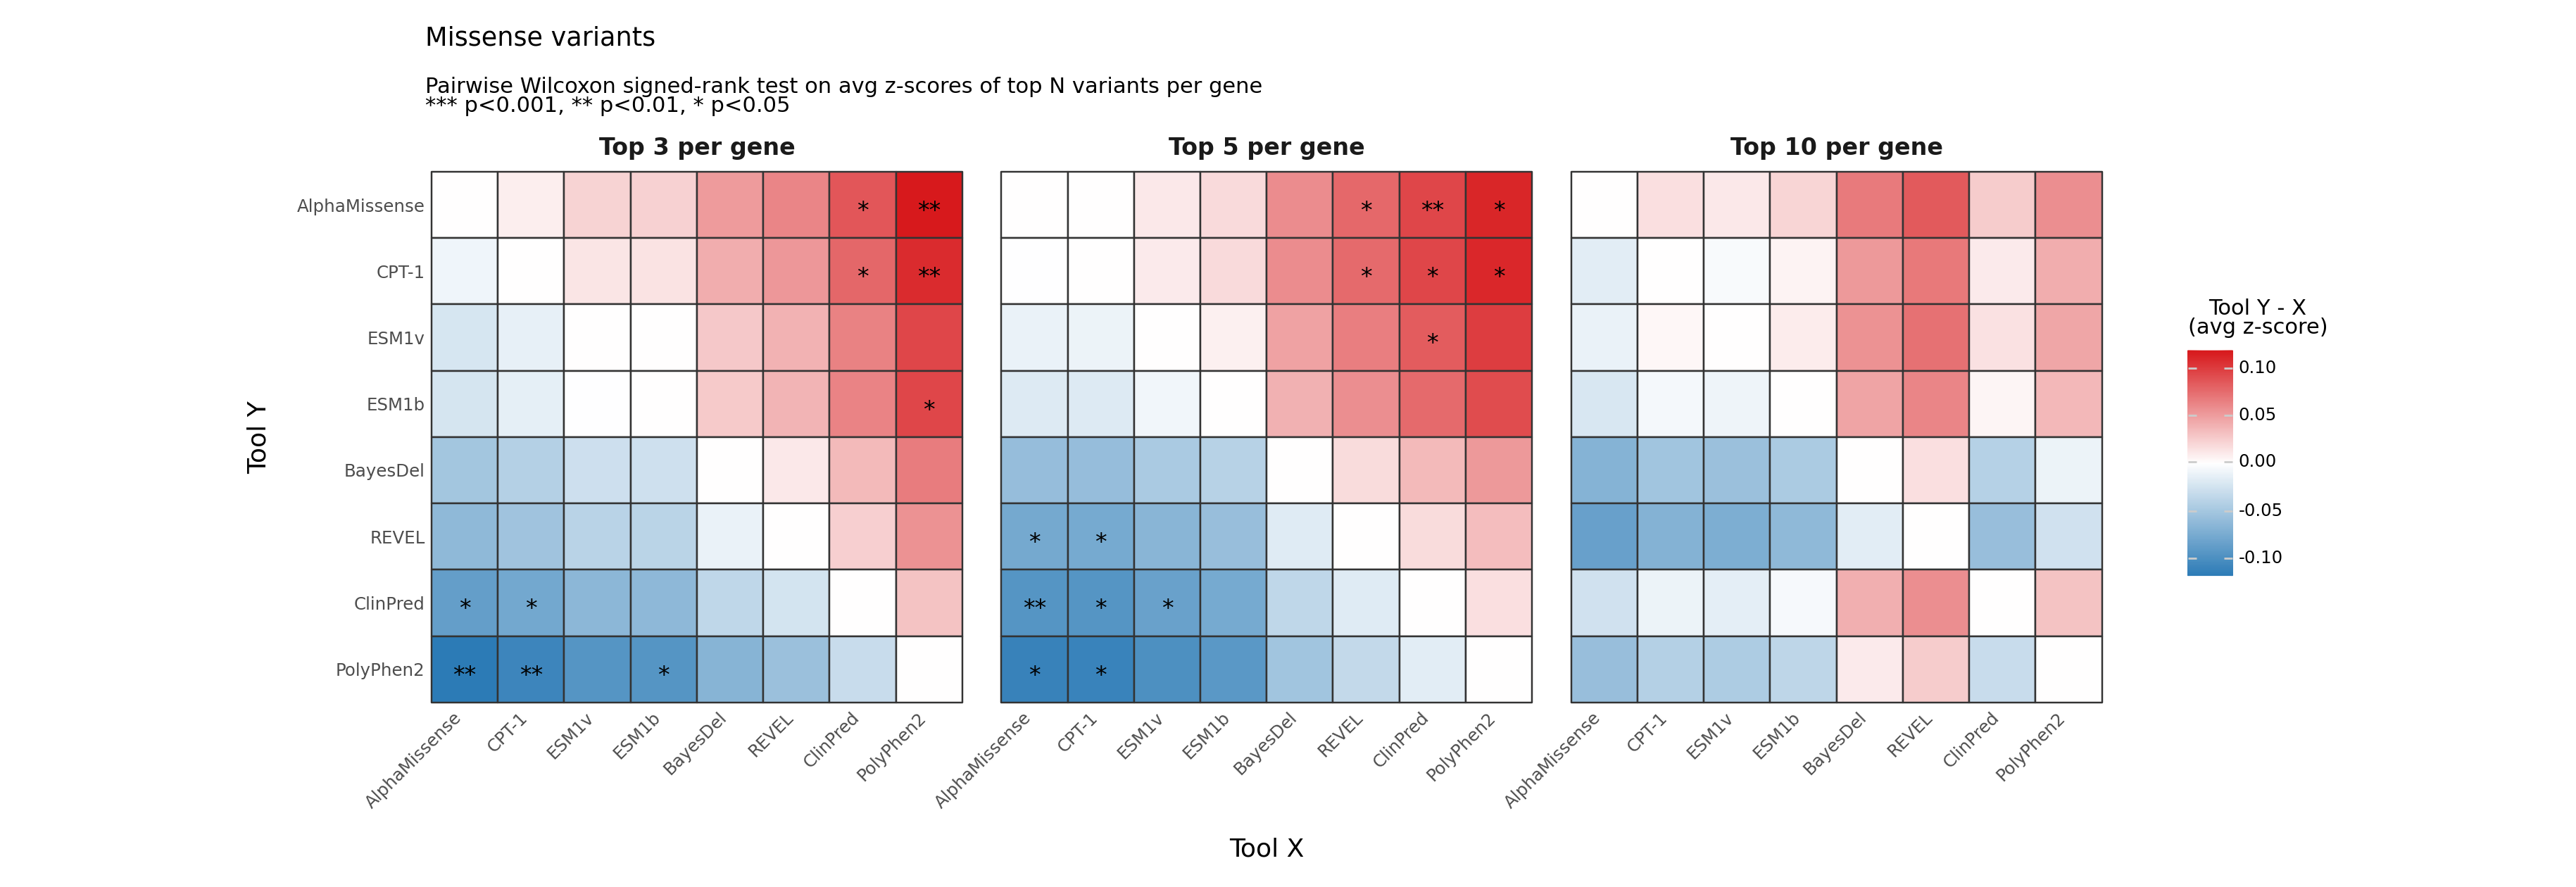

In [13]:
import pandas as pd
import itertools

# Build annotation name -> label mapping
anno_to_label = dict(zip(
    anno_config_df['annotation'].to_list(),
    anno_config_df['label'].to_list()
))

# Filter tools (exclude promoterai_over)
plot_annotations = [a for a in annotations_list if a not in ['promoterai_over']]
# plot_annotations = [a for a in annotations_list if a not in ['zooverphylop', 'zoopriphylop']]

# 1. Order tools by mean gene z-score at smallest N (Top 5)
smallest_n = target_k[0]
tool_means = {}
for ann in plot_annotations:
    sub = gene_topn.filter(
        (pl.col('annotation') == ann) & (pl.col('top_n') == smallest_n)
    )
    tool_means[ann] = float(sub['gene_topn_zscore'].mean())

ordered_tools  = sorted(tool_means.keys(), key=lambda x: tool_means[x], reverse=True)
ordered_labels = [anno_to_label.get(t, t) for t in ordered_tools]

# 2. Pairwise Wilcoxon signed-rank test on paired per-gene z-scores
heatmap_data = []

for n_val in target_k:
    for ann_x, ann_y in itertools.product(ordered_tools, repeat=2):
        label_x = anno_to_label.get(ann_x, ann_x)
        label_y = anno_to_label.get(ann_y, ann_y)

        if ann_x == ann_y:
            heatmap_data.append({
                'Window': f"Top {n_val:,} per gene",
                'Window_Int': n_val,
                'Tool_X': label_x,
                'Tool_Y': label_y,
                'mean_diff': 0.0,
                'sig': ''
            })
            continue

        # Get paired gene z-scores (inner join → only genes present in both tools)
        df_x = gene_topn.filter(
            (pl.col('annotation') == ann_x) & (pl.col('top_n') == n_val)
        ).select(['region', 'gene_topn_zscore'])

        df_y = gene_topn.filter(
            (pl.col('annotation') == ann_y) & (pl.col('top_n') == n_val)
        ).select(['region', 'gene_topn_zscore'])

        paired = df_x.join(df_y, on='region', suffix='_y')
        z_x = paired['gene_topn_zscore'].to_numpy()
        z_y = paired['gene_topn_zscore_y'].to_numpy()

        mean_diff = float(z_y.mean() - z_x.mean())
        # median_diff = float(np.median(z_y) - np.median(z_x))

        if len(z_x) >= 10 and not np.allclose(z_x, z_y):
            _, p_val = stats.wilcoxon(z_x, z_y, alternative='two-sided')
        else:
            p_val = 1.0

        if p_val < 0.001: sig = '***'
        elif p_val < 0.01: sig = '**'
        elif p_val < 0.05: sig = '*'
        else: sig = ''

        heatmap_data.append({
            'Window': f"Top {n_val:,} per gene",
            'Window_Int': n_val,
            'Tool_X': label_x,
            'Tool_Y': label_y,
            'mean_diff': mean_diff,
            'sig': sig
        })

df_heat = pd.DataFrame(heatmap_data)
df_heat = df_heat.sort_values('Window_Int')

# Lock in the categorical order so best tools appear top/right
df_heat['Window'] = pd.Categorical(df_heat['Window'], categories=df_heat['Window'].unique(), ordered=True)
df_heat['Tool_X'] = pd.Categorical(df_heat['Tool_X'], categories=ordered_labels, ordered=True)
df_heat['Tool_Y'] = pd.Categorical(df_heat['Tool_Y'], categories=ordered_labels[::-1], ordered=True)

n_facets = len(target_k)
n_tools  = len(ordered_tools)

(
    ggplot(df_heat, aes(x='Tool_X', y='Tool_Y', fill='mean_diff'))
    + geom_tile(color="#333333", size=0.5)
    + geom_text(aes(label='sig'), color="black", size=12, va='center', nudge_y=-0.1)
    + facet_wrap('~Window', ncol=n_facets)
    + scale_fill_gradient2(low="#2C7BB6", mid="#FFFFFF", high="#D7191C", midpoint=0)
    + labs(
        title=f"{vc['x_label']} variants",
        subtitle="Pairwise Wilcoxon signed-rank test on avg z-scores of top N variants per gene\n*** p<0.001, ** p<0.01, * p<0.05",
        x="Tool X",
        y="Tool Y",
        fill="Tool Y - X\n(avg z-score)"
    )
    + theme_minimal()
    + theme(
        figure_size=(n_facets * (n_tools * 0.6 + 0.8) + 1.5, n_tools * 0.6 + 1.5),
        aspect_ratio=1,
        axis_title=element_text(size=13, lineheight=1.4),
        axis_text_x=element_text(rotation=45, hjust=1),
        strip_text=element_text(size=12, face='bold'),
        panel_grid=element_blank(),
        legend_background=element_rect(fill="white", color='white', alpha=0.8),
        plot_background=element_rect(fill="white", color="white"),
    )
)

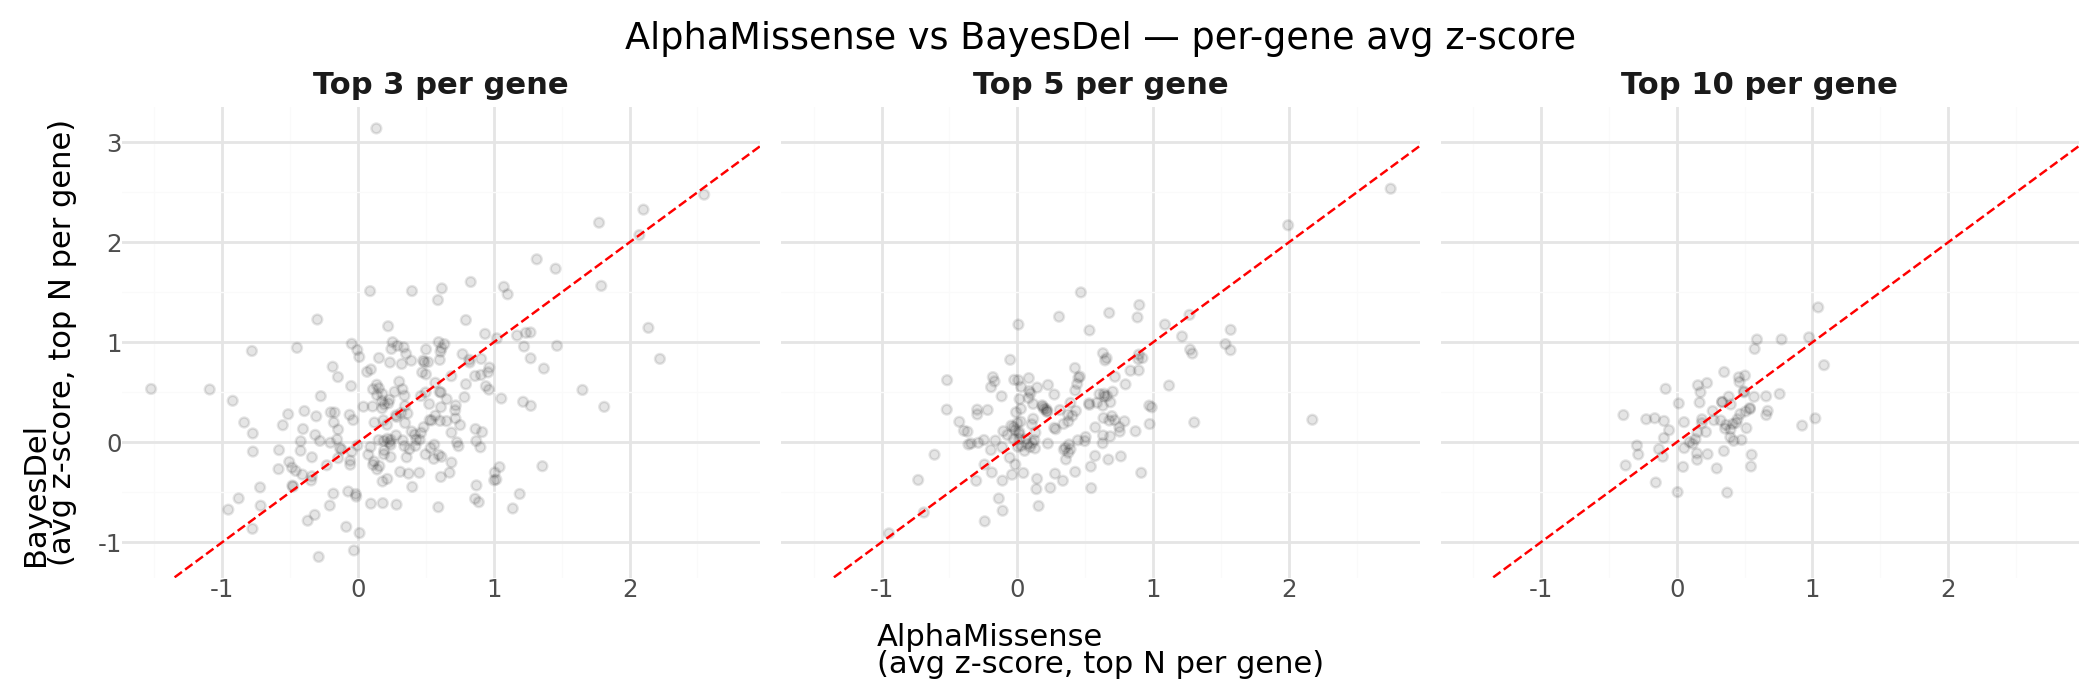

In [14]:
# Scatter plot: per-gene avg z-scores for two tools
# Default: first two tools alphabetically from the filtered set
scatter_ann_x, scatter_ann_y = sorted(ordered_tools)[:2]
# scatter_ann_x = 'am_pathogenicity'
# scatter_ann_y = 'clin'

label_x = anno_to_label.get(scatter_ann_x, scatter_ann_x)
label_y = anno_to_label.get(scatter_ann_y, scatter_ann_y)

scatter_dfs = []
for n_val in target_k:
    df_x = gene_topn.filter(
        (pl.col('annotation') == scatter_ann_x) & (pl.col('top_n') == n_val)
    ).select(['region', 'gene_topn_zscore'])

    df_y = gene_topn.filter(
        (pl.col('annotation') == scatter_ann_y) & (pl.col('top_n') == n_val)
    ).select(['region', 'gene_topn_zscore'])

    paired = (
        df_x.join(df_y, on='region', suffix='_y')
        .with_columns(top_n_label=pl.lit(f"Top {n_val:,} per gene"))
    )
    scatter_dfs.append(paired)

scatter_df = pl.concat(scatter_dfs).to_pandas()
scatter_df['top_n_label'] = pd.Categorical(
    scatter_df['top_n_label'],
    categories=[f"Top {n:,} per gene" for n in target_k],
    ordered=True
)

(
    ggplot(scatter_df, aes(x='gene_topn_zscore', y='gene_topn_zscore_y'))
    + geom_point(alpha=0.1, size=1.5)
    + geom_abline(slope=1, intercept=0, color='red', linetype='dashed')
    + facet_wrap('~top_n_label', ncol=len(target_k))
    + labs(
        title=f"{label_x} vs {label_y} — per-gene avg z-score",
        x=f"{label_x}\n(avg z-score, top N per gene)",
        y=f"{label_y}\n(avg z-score, top N per gene)",
    )
    + theme_minimal()
    + theme(
        figure_size=(len(target_k) * 3.5, 3.5),
        strip_text=element_text(size=11, face='bold'),
        plot_background=element_rect(fill="white", color="white"),
    )
)